In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv("data.csv")

In [3]:
df

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,C001,Male,0,Yes,No,12,Yes,Fiber optic,Month-to-month,Electronic check,75.5,906.0,Yes
1,C002,Female,0,No,No,36,Yes,DSL,One year,Credit card,55.2,1987.2,No
2,C003,Male,1,Yes,No,5,Yes,Fiber optic,Month-to-month,Electronic check,89.9,449.5,Yes
3,C004,Female,0,Yes,Yes,60,Yes,DSL,Two year,Bank transfer,45.0,2700.0,No
4,C005,Male,0,No,No,8,Yes,Fiber optic,Month-to-month,Mailed check,95.4,763.2,Yes
5,C006,Female,0,Yes,Yes,72,Yes,DSL,Two year,Credit card,42.3,3045.6,No
6,C007,Male,1,No,No,3,No,No,Month-to-month,Electronic check,20.0,60.0,Yes
7,C008,Female,0,Yes,Yes,48,Yes,Fiber optic,One year,Bank transfer,80.1,3844.8,No
8,C009,Male,0,No,No,18,Yes,DSL,Month-to-month,Mailed check,60.5,1089.0,Yes
9,C010,Female,0,Yes,No,24,Yes,Fiber optic,One year,Credit card,78.4,1881.6,No


In [4]:
df.head()

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,C001,Male,0,Yes,No,12,Yes,Fiber optic,Month-to-month,Electronic check,75.5,906.0,Yes
1,C002,Female,0,No,No,36,Yes,DSL,One year,Credit card,55.2,1987.2,No
2,C003,Male,1,Yes,No,5,Yes,Fiber optic,Month-to-month,Electronic check,89.9,449.5,Yes
3,C004,Female,0,Yes,Yes,60,Yes,DSL,Two year,Bank transfer,45.0,2700.0,No
4,C005,Male,0,No,No,8,Yes,Fiber optic,Month-to-month,Mailed check,95.4,763.2,Yes


In [5]:
X = df.drop(["CustomerID", "Churn"], axis=1).copy()
y = df["Churn"].copy()

In [6]:
le = LabelEncoder()

In [7]:
encoders = {}
for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le


C:\Users\coode\AppData\Local\Temp\ipykernel_22884\3600850360.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include="object").columns:


In [8]:
y = LabelEncoder().fit_transform(y)

In [9]:
print(X.head())
print(X.dtypes)

   Gender  SeniorCitizen  Partner  Dependents  Tenure  PhoneService  \
0       1              0        1           0      12             1   
1       0              0        0           0      36             1   
2       1              1        1           0       5             1   
3       0              0        1           1      60             1   
4       1              0        0           0       8             1   

   InternetService  Contract  PaymentMethod  MonthlyCharges  TotalCharges  
0                1         0              2            75.5         906.0  
1                0         1              1            55.2        1987.2  
2                1         0              2            89.9         449.5  
3                0         2              0            45.0        2700.0  
4                1         0              3            95.4         763.2  
Gender               int64
SeniorCitizen        int64
Partner              int64
Dependents           int64
Tenure   

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [11]:
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 15 | Test: 5


In [12]:
model = RandomForestClassifier(random_state=42)

In [13]:
print(X.dtypes)

Gender               int64
SeniorCitizen        int64
Partner              int64
Dependents           int64
Tenure               int64
PhoneService         int64
InternetService      int64
Contract             int64
PaymentMethod        int64
MonthlyCharges     float64
TotalCharges       float64
dtype: object


In [14]:
print(X.head())
print(X.dtypes)

   Gender  SeniorCitizen  Partner  Dependents  Tenure  PhoneService  \
0       1              0        1           0      12             1   
1       0              0        0           0      36             1   
2       1              1        1           0       5             1   
3       0              0        1           1      60             1   
4       1              0        0           0       8             1   

   InternetService  Contract  PaymentMethod  MonthlyCharges  TotalCharges  
0                1         0              2            75.5         906.0  
1                0         1              1            55.2        1987.2  
2                1         0              2            89.9         449.5  
3                0         2              0            45.0        2700.0  
4                1         0              3            95.4         763.2  
Gender               int64
SeniorCitizen        int64
Partner              int64
Dependents           int64
Tenure   

In [15]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [16]:
y_pred = model.predict(X_test)

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [19]:
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 100.00%


In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [21]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[3 0]
 [0 2]]


In [22]:
plt.figure(figsize=(5,4))

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

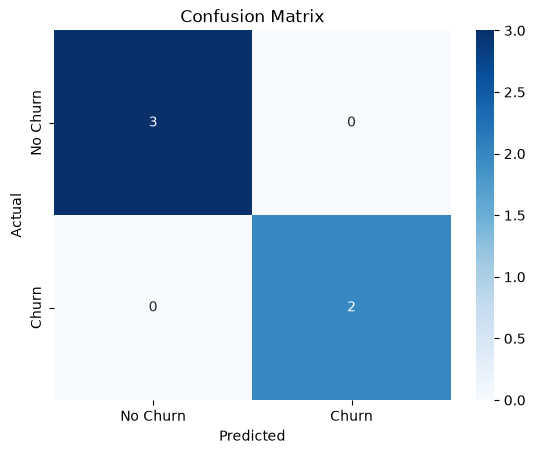

In [24]:
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["No Churn","Churn"],
            yticklabels=["No Churn","Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [25]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

            Feature  Importance
7          Contract    0.336726
10     TotalCharges    0.256624
4            Tenure    0.211698
8     PaymentMethod    0.053088
9    MonthlyCharges    0.046309
2           Partner    0.032169
0            Gender    0.024747
3        Dependents    0.018345
6   InternetService    0.018139
5      PhoneService    0.002156
1     SeniorCitizen    0.000000


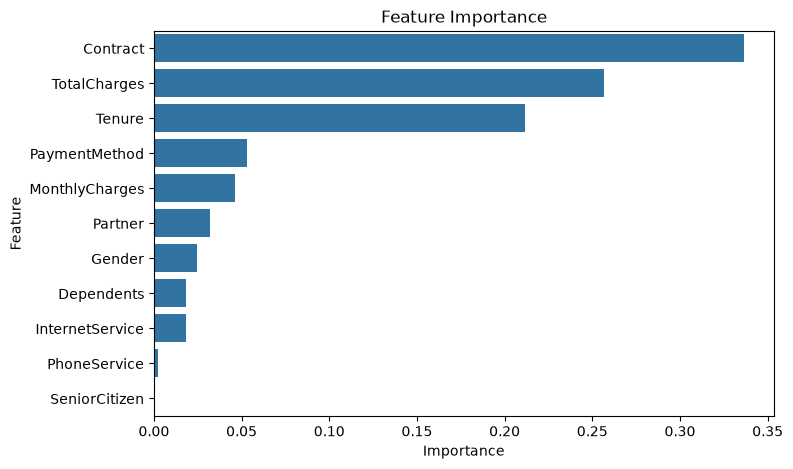

In [26]:
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feature_importance)

plt.title("Feature Importance")
plt.show()

In [27]:
new_customer_raw = {
    "Gender": "Male",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "Tenure": 20,
    "PhoneService": "Yes",
    "InternetService": "DSL",
    "Contract": "Month-to-month",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 70.5,
    "TotalCharges": 1410
}

new_customer = pd.DataFrame([new_customer_raw])
for col in encoders:
    new_customer[col] = encoders[col].transform(new_customer[col])

prediction = model.predict(new_customer[X.columns])

if prediction[0] == 1:
    print("Customer is likely to Churn.")
else:
    print("Customer is not likely to Churn.")


Customer is likely to Churn.


In [30]:
print("===== Customer Churn Prediction =====")

gender = int(input("Gender (Male=1, Female=0): "))
senior = int(input("Senior Citizen (Yes=1, No=0): "))
partner = int(input("Partner (Yes=1, No=0): "))
dependents = int(input("Dependents (Yes=1, No=0): "))
tenure = int(input("Tenure (Months): "))
phone = int(input("Phone Service (Yes=1, No=0): "))
internet = int(input("Internet Service (No=0, DSL=1, Fiber Optic=2): "))
contract = int(input("Contract (Month-to-month=0, One year=1, Two year=2): "))
payment = int(input("Payment Method (Bank Transfer=0, Credit Card=1, Electronic Check=2, Mailed Check=3): "))
monthly = float(input("Monthly Charges: "))
total = float(input("Total Charges: "))

customer = pd.DataFrame([[
    gender,
    senior,
    partner,
    dependents,
    tenure,
    phone,
    internet,
    contract,
    payment,
    monthly,
    total
]], columns=X.columns)

prediction = model.predict(customer)

if prediction[0] == 1:
    print("\nPrediction: Customer is likely to CHURN.")
else:
    print("\nPrediction: Customer is NOT likely to churn.")

===== Customer Churn Prediction =====

Prediction: Customer is likely to CHURN.
